In [363]:
# Import packages (pip install <package-name>)
import yfinance as yf

import pandas as pd
import numpy as np
from scipy.stats import norm

import seaborn as sns
import matplotlib.mlab as mlab
import matplotlib.pyplot as plt
import plotly.express as px

In [364]:
# Global Variables 
LINK = "LINK-USD"
BTC = "BTC-USD"

## Chainlink (LINK) Market Outlook and Quantitative Scenario Analysis

In [365]:
# Get Market Data (LINK & BTC All-Time)

link_ticker = yf.Ticker(LINK)
link_hist = link_ticker.history(period="max")


btc_tiker = yf.Ticker(BTC)
btc_hist = btc_tiker.history(period="max")

In [366]:
print(f'==================== INFO ====================')
print(link_hist.info())
link_hist = link_hist[["Close", "Volume"]]

print(f'==================== How many NA? ====================')
print(link_hist.isna().sum())

print(f'==================== DESCRIBE ====================')
print(link_hist.describe())

==================== INFO ====================
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3044 entries, 2017-11-09 00:00:00+00:00 to 2026-03-11 00:00:00+00:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          3044 non-null   float64
 1   High          3044 non-null   float64
 2   Low           3044 non-null   float64
 3   Close         3044 non-null   float64
 4   Volume        3044 non-null   int64  
 5   Dividends     3044 non-null   float64
 6   Stock Splits  3044 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 190.2 KB
None
==================== How many NA? ====================
Close     0
Volume    0
dtype: int64
==================== DESCRIBE ====================
             Close        Volume
count  3044.000000  3.044000e+03
mean     10.704314  6.652021e+08
std       9.035845  3.175077e+09
min       0.145255  3.987730e+05
25%       2.484453  1.200691e+08
50%       8.59

In [367]:
print(f'==================== INFO ====================')
print(btc_hist.info())
btc_hist = btc_hist[["Close", "Volume"]]
print(f'==================== How many NA? ====================')
print(btc_hist.isna().sum())

print(f'==================== DESCRIBE ====================')
print(btc_hist.describe())

==================== INFO ====================
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4193 entries, 2014-09-17 00:00:00+00:00 to 2026-03-11 00:00:00+00:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          4193 non-null   float64
 1   High          4193 non-null   float64
 2   Low           4193 non-null   float64
 3   Close         4193 non-null   float64
 4   Volume        4193 non-null   int64  
 5   Dividends     4193 non-null   float64
 6   Stock Splits  4193 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 262.1 KB
None
==================== How many NA? ====================
Close     0
Volume    0
dtype: int64
==================== DESCRIBE ====================
               Close        Volume
count    4193.000000  4.193000e+03
mean    27698.558844  2.202074e+10
std     32102.913672  2.303376e+10
min       178.102997  5.914570e+06
25%      2863.199951  1.443970e+09
50

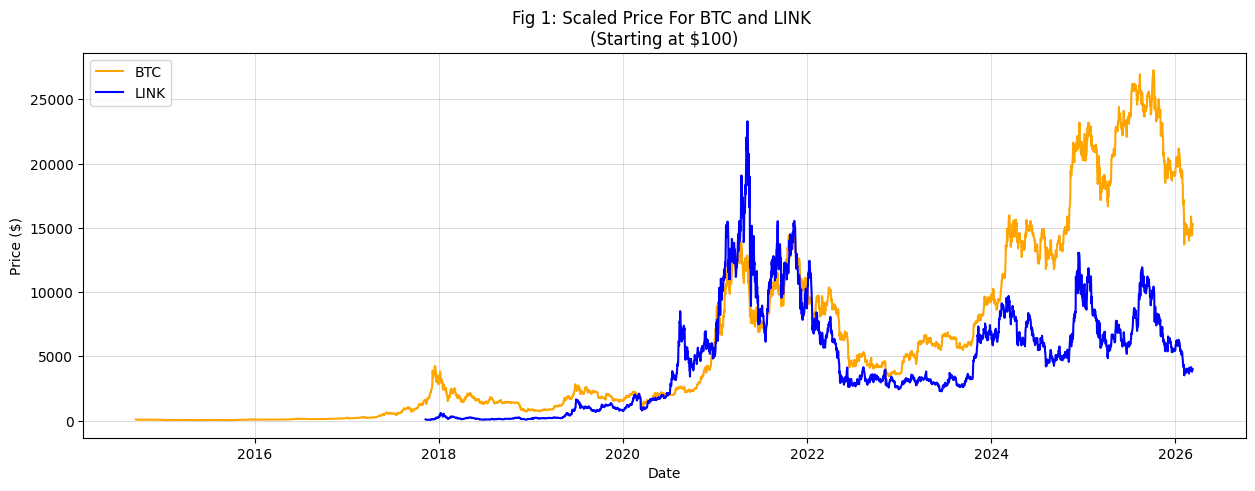

In [ ]:

btc = btc_hist["scaled_close"] = (btc_hist["Close"] / btc_hist["Close"].iloc[0]) * 100
link = link_hist["scaled_close"] = (link_hist["Close"] / link_hist["Close"].iloc[0]) * 100

fig, ax = plt.subplots(1,1)
fig.set_size_inches(15,5)

ax.plot(btc, label="BTC", color="orange")
ax.plot(link, label="LINK", color="blue")

ax.set_xlabel("Date")
ax.set_ylabel("Price ($)")
ax.set_title("Fig 1: Stanndarized Closing Price For BTC and LINK \n(Starting at $100)")
ax.grid(True,  linewidth=0.5, alpha=0.6)
ax.legend()


## Data is clean and ready to go so now we can calculate the features.

- First ***Log Returns***

$$
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)
$$

or more generaly

$$
r_t = \ln\left(\frac{P_{t+\Delta t}}{P_t}\right)
$$

Where:

- $r_t$ = log return at time $t$
- $P_t$ = asset price at time $t$
- $P_{t-1}$ = asset price at the previous time step
- $\ln$ = natural logarithm

In [369]:
# LINK
link_hist = link_hist.sort_index()
link_hist["t-1"] =  link_hist["Close"].shift(1)
link_hist["Log_returns"] = np.log ((link_hist["Close"] ) / (link_hist["t-1"])) 
link_hist = link_hist[["Close", "Log_returns", "Volume"]].dropna()
link_hist

,Close,Log_returns,Volume
Date,,,
2017-11-10 00:00:00+00:00,0.187602,-0.177185,2125460
2017-11-11 00:00:00+00:00,0.179770,-0.042644,2238980
2017-11-12 00:00:00+00:00,0.170898,-0.050611,5455200
2017-11-13 00:00:00+00:00,0.183071,0.068807,2992650
2017-11-14 00:00:00+00:00,0.188114,0.027174,2203410
...,...,...,...
2026-03-06 00:00:00+00:00,8.793666,-0.044832,676654703
2026-03-07 00:00:00+00:00,8.694978,-0.011286,418422310
2026-03-08 00:00:00+00:00,8.523437,-0.019926,547922531


In [370]:
# BTC
btc_hist = btc_hist.sort_index()
btc_hist["t-1"] =  btc_hist["Close"].shift(1)
btc_hist["Log_returns"] = np.log ((btc_hist["Close"] ) / (btc_hist["t-1"])) 
btc_hist = btc_hist[["Close", "Log_returns", "Volume"]].dropna()
btc_hist

,Close,Log_returns,Volume
Date,,,
2014-09-18 00:00:00+00:00,424.440002,-0.074643,34483200
2014-09-19 00:00:00+00:00,394.795990,-0.072402,37919700
2014-09-20 00:00:00+00:00,408.903992,0.035111,36863600
2014-09-21 00:00:00+00:00,398.821014,-0.024968,26580100
2014-09-22 00:00:00+00:00,402.152008,0.008317,24127600
...,...,...,...
2026-03-06 00:00:00+00:00,68136.492188,-0.038927,43776962871
2026-03-07 00:00:00+00:00,67272.593750,-0.012760,23258701211
2026-03-08 00:00:00+00:00,65969.781250,-0.019556,33195080116


## Now We Have To Calculate The 50-Day and 200-Day Moving Average (MA)

$$
SMA_{50}(t) = \frac{1}{50} \sum_{i=0}^{49} P_{t-i}
$$

$$
SMA_{200}(t) = \frac{1}{200} \sum_{i=0}^{199} P_{t-i}
$$

Where:

- $SMA_n(t)$ = Simple Moving Average over $n$ periods at time $t$
- $P_t$ = asset price at time $t$
- $n$ = number of periods included in the average



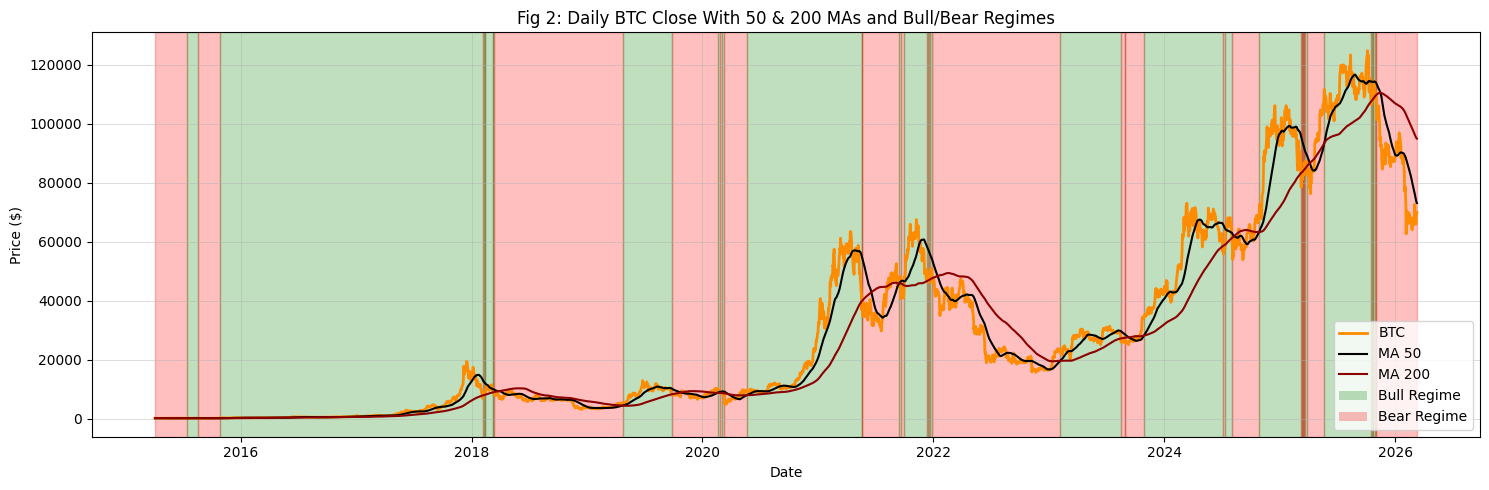

In [371]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

btc_hist["ma_50"] = btc_hist["Close"].rolling(window=50).mean()
btc_hist["ma_200"] = btc_hist["Close"].rolling(window=200).mean()
btc_hist.dropna(inplace=True)

btc_hist["Bear_Regime"] = (
    (btc_hist["Close"] > btc_hist["ma_200"]) &
    (btc_hist["ma_50"] > btc_hist["ma_200"])
)

fig, ax = plt.subplots(1, 1)
fig.set_size_inches(15, 5)

# Shade bull / bear regimes
start_idx = btc_hist.index[0]
current_regime = btc_hist["Bear_Regime"].iloc[0]

for i in range(1, len(btc_hist)):
    if btc_hist["Bear_Regime"].iloc[i] != current_regime:
        end_idx = btc_hist.index[i]
        ax.axvspan(
            start_idx,
            end_idx,
            color="green" if current_regime else "red",
            alpha=0.25
        )
        start_idx = end_idx
        current_regime = btc_hist["Bear_Regime"].iloc[i]

# Shade final segment
ax.axvspan(
    start_idx,
    btc_hist.index[-1],
    color="green" if current_regime else "red",
    alpha=0.25
)

# price + moving averages
ax.plot(btc_hist.index, btc_hist["Close"], label="BTC", color="darkorange", linewidth=2)
ax.plot(btc_hist.index, btc_hist["ma_50"], label="MA 50", color="black", linewidth=1.5)
ax.plot(btc_hist.index, btc_hist["ma_200"], label="MA 200", color="darkred", linewidth=1.5)

ax.set_xlabel("Date")
ax.set_ylabel("Price ($)")
ax.set_title("Fig 2: Daily BTC Close With 50 & 200 MAs and Bull/Bear Regimes")
ax.grid(True, linewidth=0.5, alpha=0.6)

#legend
bull_patch = Patch(facecolor="green", alpha=0.25, label="Bull Regime")
bear_patch = Patch(facecolor="red", alpha=0.25, label="Bear Regime")
ax.legend(handles=ax.get_lines() + [bull_patch, bear_patch], loc="lower right", bbox_to_anchor=(1, 0))
plt.tight_layout()
plt.show()

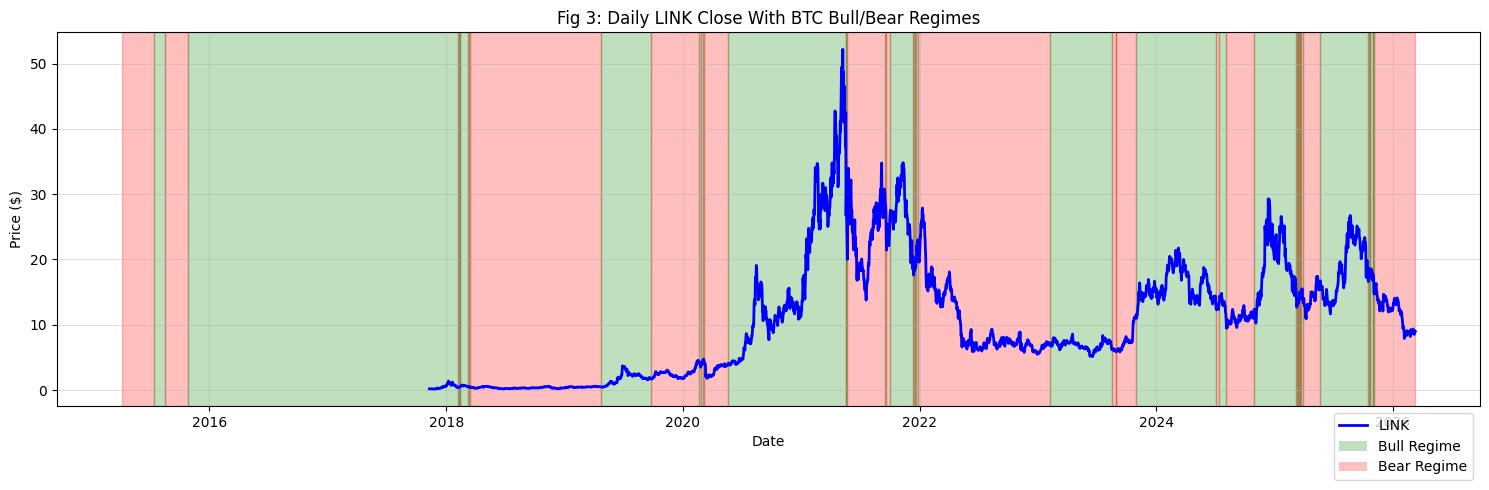

In [372]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(15, 5)

# Shade bull / bear regimes
start_idx = btc_hist.index[0]
current_regime = btc_hist["Bear_Regime"].iloc[0]

for i in range(1, len(btc_hist)):
    if btc_hist["Bear_Regime"].iloc[i] != current_regime:
        end_idx = btc_hist.index[i]
        ax.axvspan(
            start_idx,
            end_idx,
            color="green" if current_regime else "red",
            alpha=0.25
        )
        start_idx = end_idx
        current_regime = btc_hist["Bear_Regime"].iloc[i]

# Shade final segment
ax.axvspan(
    start_idx,
    btc_hist.index[-1],
    color="green" if current_regime else "red",
    alpha=0.25
)

# price + moving averages


ax.plot(link_hist.index, link_hist["Close"], label="LINK", color="blue", linewidth=2)

ax.set_xlabel("Date")
ax.set_ylabel("Price ($)")
ax.set_title("Fig 3: Daily LINK Close With BTC Bull/Bear Regimes")
ax.grid(True, linewidth=0.5, alpha=0.6)

#legend
bull_patch = Patch(facecolor="green", alpha=0.25, label="Bull Regime")
bear_patch = Patch(facecolor="red", alpha=0.25, label="Bear Regime")
ax.legend(handles=ax.get_lines() + [bull_patch, bear_patch], loc="upper right", bbox_to_anchor=(1, 0))
plt.tight_layout()
plt.show()

# Finally We Can dive into the Data, First log returns

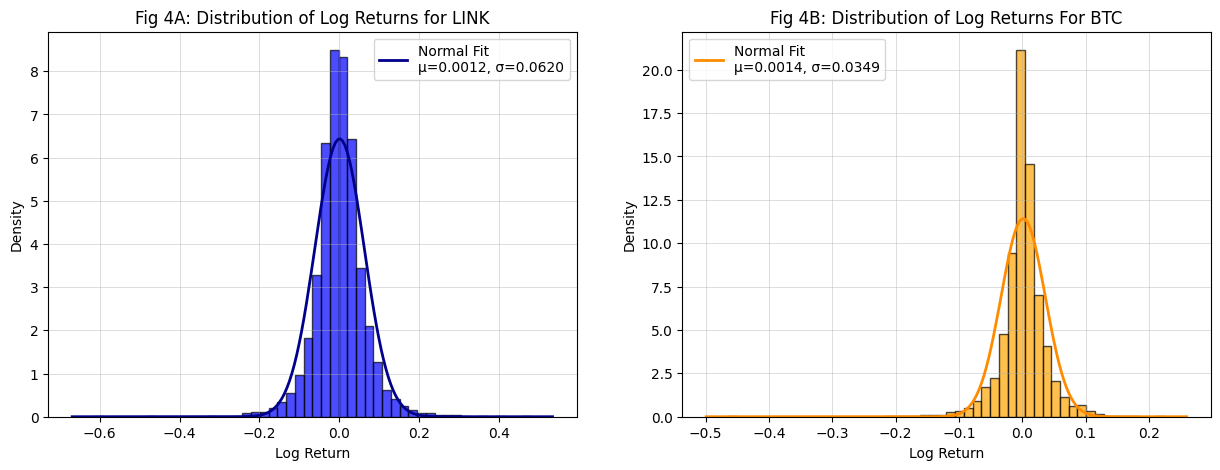

In [377]:
fig, ax = plt.subplots(1,2)
fig.set_size_inches(15,5)


# =====================================================
#                   LINK GRAPH
# =====================================================

counts, bins, patches = ax[0].hist(link_hist["Log_returns"], density=True, bins=50, color="blue", edgecolor="black", alpha=0.7)

mu, std = norm.fit(link_hist["Log_returns"])

xmin, xmax = ax[0].get_xlim()
x = np.linspace(xmin, xmax, 200)
p = norm.pdf(x, mu, std)

ax[0].plot(x, p, linewidth=2, label=f"Normal Fit\nμ={mu:.4f}, σ={std:.4f}", color="darkblue")
ax[0].set_xlabel("Log Return")
ax[0].set_ylabel("Density")
ax[0].set_title("Fig 4A: Distribution of Log Returns for LINK")
ax[0].grid(True, linewidth=0.5, alpha=0.6)
ax[0].legend()
 


# =====================================================
#                   BTC GRAPH
# =====================================================
counts, bins, patches = ax[1].hist(btc_hist["Log_returns"], density=True, bins=50, color="orange", edgecolor="black", alpha=0.7)

mu, std = norm.fit(btc_hist["Log_returns"])

xmin, xmax = ax[1].get_xlim()
x = np.linspace(xmin, xmax, 200)
p = norm.pdf(x, mu, std)

ax[1].plot(x, p, linewidth=2, label=f"Normal Fit\nμ={mu:.4f}, σ={std:.4f}", color="darkorange")
ax[1].set_xlabel("Log Return")
ax[1].set_ylabel("Density")
ax[1].set_title("Fig 4B: Distribution of Log Returns For BTC")
ax[1].grid(True,  linewidth=0.5, alpha=0.6)
ax[1].legend()

plt.show()

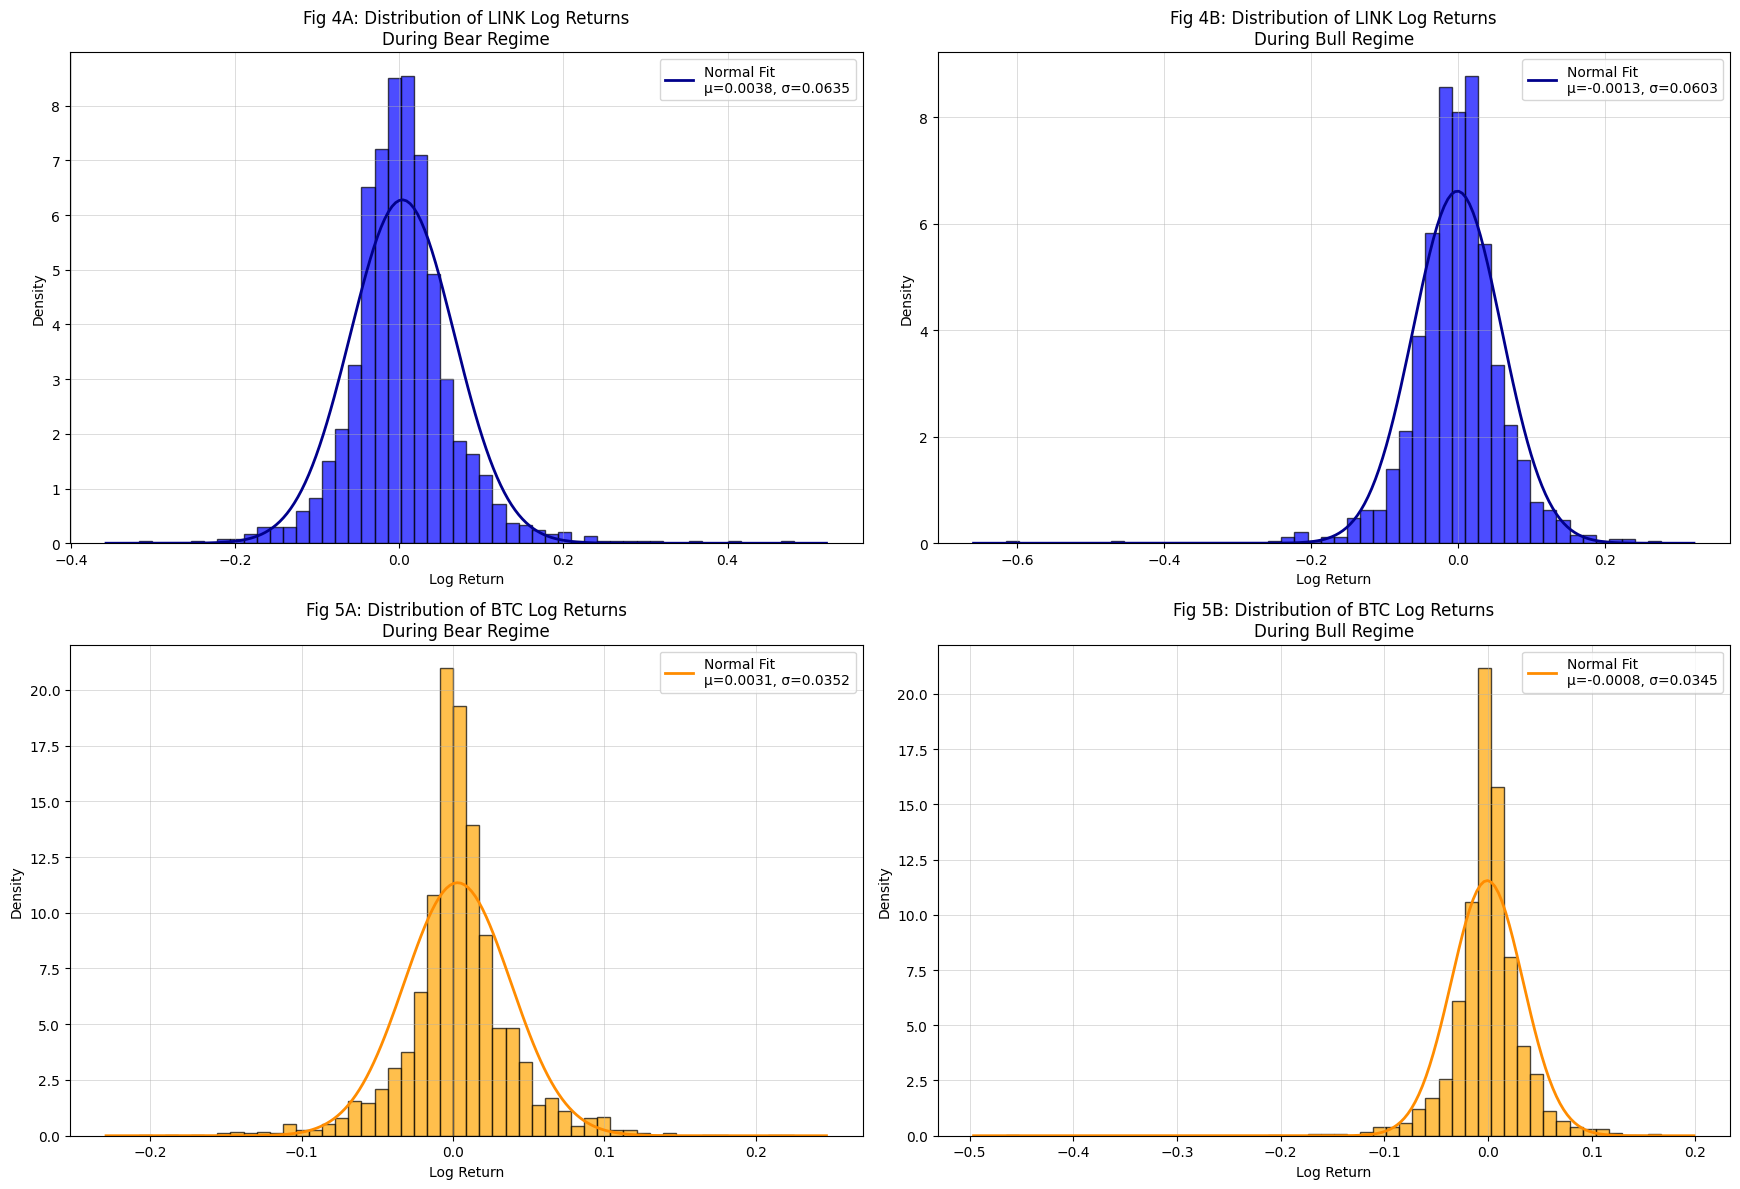

In [380]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

fig, ax = plt.subplots(2, 2, figsize=(17.5, 12))
ax = ax.ravel()

# =====================================================
#                   LINK GRAPH
# =====================================================
c = pd.merge(link_hist, btc_hist, left_index=True, right_index=True, how='left')

# LINK - Bear
bear = c[c["Bear_Regime"] == True]["Log_returns_x"].dropna()
counts, bins, patches = ax[0].hist(
    bear, density=True, bins=50, color="blue", edgecolor="black", alpha=0.7
)

mu, std = norm.fit(bear)
xmin, xmax = ax[0].get_xlim()
x = np.linspace(xmin, xmax, 200)
p = norm.pdf(x, mu, std)

ax[0].plot(x, p, linewidth=2, label=f"Normal Fit\nμ={mu:.4f}, σ={std:.4f}", color="darkblue")
ax[0].set_xlabel("Log Return")
ax[0].set_ylabel("Density")
ax[0].set_title("Fig 4A: Distribution of LINK Log Returns\nDuring Bear Regime")
ax[0].grid(True, linewidth=0.5, alpha=0.6)
ax[0].legend()

# LINK - Bull
bull = c[c["Bear_Regime"] == False]["Log_returns_x"].dropna()
counts, bins, patches = ax[1].hist(
    bull, density=True, bins=50, color="blue", edgecolor="black", alpha=0.7
)

mu, std = norm.fit(bull)
xmin, xmax = ax[1].get_xlim()
x = np.linspace(xmin, xmax, 200)
p = norm.pdf(x, mu, std)

ax[1].plot(x, p, linewidth=2, label=f"Normal Fit\nμ={mu:.4f}, σ={std:.4f}", color="darkblue")
ax[1].set_xlabel("Log Return")
ax[1].set_ylabel("Density")
ax[1].set_title("Fig 4B: Distribution of LINK Log Returns\nDuring Bull Regime")
ax[1].grid(True, linewidth=0.5, alpha=0.6)
ax[1].legend()

# =====================================================
#                   BTC GRAPH
# =====================================================

# BTC - Bear
bear = btc_hist[btc_hist["Bear_Regime"] == True]["Log_returns"].dropna()
counts, bins, patches = ax[2].hist(
    bear, density=True, bins=50, color="orange", edgecolor="black", alpha=0.7
)

mu, std = norm.fit(bear)
xmin, xmax = ax[2].get_xlim()
x = np.linspace(xmin, xmax, 200)
p = norm.pdf(x, mu, std)

ax[2].plot(x, p, linewidth=2, label=f"Normal Fit\nμ={mu:.4f}, σ={std:.4f}", color="darkorange")
ax[2].set_xlabel("Log Return")
ax[2].set_ylabel("Density")
ax[2].set_title("Fig 5A: Distribution of BTC Log Returns\nDuring Bear Regime")
ax[2].grid(True, linewidth=0.5, alpha=0.6)
ax[2].legend()

# BTC - Bull
bull = btc_hist[btc_hist["Bear_Regime"] == False]["Log_returns"].dropna()
counts, bins, patches = ax[3].hist(
    bull, density=True, bins=50, color="orange", edgecolor="black", alpha=0.7
)

mu, std = norm.fit(bull)
xmin, xmax = ax[3].get_xlim()
x = np.linspace(xmin, xmax, 200)
p = norm.pdf(x, mu, std)

ax[3].plot(x, p, linewidth=2, label=f"Normal Fit\nμ={mu:.4f}, σ={std:.4f}", color="darkorange")
ax[3].set_xlabel("Log Return")
ax[3].set_ylabel("Density")
ax[3].set_title("Fig 5B: Distribution of BTC Log Returns\nDuring Bull Regime")
ax[3].grid(True, linewidth=0.5, alpha=0.6)
ax[3].legend()

plt.tight_layout()
plt.show()

In [ ]:
c = pd.merge(link_hist, btc_hist, left_index=True, right_index=True, how='inner')
c

,Close_x,Log_returns_x,Volume_x,Close_y,Log_returns_y,Volume_y,ma_50,ma_200,Bear_Regime
Date,,,,,,,,,
2017-11-10 00:00:00+00:00,0.187602,-0.177185,2125460,6618.140137,-0.076400,5208249856,5463.864790,3517.214644,True
2017-11-11 00:00:00+00:00,0.179770,-0.042644,2238980,6357.600098,-0.040163,4908680192,5518.402793,3542.675194,True
2017-11-12 00:00:00+00:00,0.170898,-0.050611,5455200,5950.069824,-0.066248,8957349888,5561.556191,3566.020143,True
2017-11-13 00:00:00+00:00,0.183071,0.068807,2992650,6559.490234,0.097510,6263249920,5619.089194,3592.228945,True
2017-11-14 00:00:00+00:00,0.188114,0.027174,2203410,6635.750000,0.011559,3197110016,5673.282793,3618.825295,True
...,...,...,...,...,...,...,...,...,...
2026-03-06 00:00:00+00:00,8.793666,-0.044832,676654703,68136.492188,-0.038927,43776962871,75291.032734,95895.056270,False
2026-03-07 00:00:00+00:00,8.694978,-0.011286,418422310,67272.593750,-0.012760,23258701211,74725.982266,95667.263340,False
2026-03-08 00:00:00+00:00,8.523437,-0.019926,547922531,65969.781250,-0.019556,33195080116,74143.379453,95425.738535,False


<!--  -->